# Day 8 — Statistical Analysis

Days 1–7 built a production-quality warehouse (staging → dims/facts → business marts) on
Neon Postgres via dbt. This notebook uses that warehouse to answer three business questions
with actual statistical tests, not just SQL aggregates.

No SQL below — everything reads from the already-built marts (`mart_finance_scorecard`,
`mart_burden_vs_community`, `mart_service_line_margin`) via `pandas.read_sql`.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

In [2]:
scorecard = pd.read_sql(
    "SELECT * FROM dbt_dev.mart_finance_scorecard",
    engine
)

burden = pd.read_sql(
    "SELECT * FROM dbt_dev.mart_burden_vs_community",
    engine
)

service_line = pd.read_sql(
    "SELECT * FROM dbt_dev.mart_service_line_margin",
    engine
)

scorecard.head()

,hospital_key,hospital_name,cbsa_code,metro_name,hospital_ownership,number_of_beds,net_patient_revenue,charity_care_cost,uncompensated_care_cost,net_income,charity_pct_of_revenue,uncompensated_pct_of_revenue
0,0004b8442e2ec3a07e8a6bcf4d76044f,UPMC NORTHWEST,36340,"Oil City, PA Micro Area",Voluntary non-profit - Other,139.0,146598613.0,1577375.0,2538461.0,-23151935.0,0.010760,0.017316
1,000b31170943ec30f8c77b978b80d6fd,"BAYHEALTH MEDICAL CENTER, KENT CAMPUS",20100,"Dover, DE Metro Area",Voluntary non-profit - Private,279.0,660143407.0,12459948.0,18679915.0,43842744.0,0.018875,0.028297
2,000d01d775ba86fc7f9141cf48c1fcdd,WHITE COUNTY MEDICAL CENTER,42620,"Searcy, AR Micro Area",Voluntary non-profit - Private,179.0,272249366.0,2510504.0,2510504.0,-12469398.0,0.009221,0.009221
3,000eb9d4c8775120d8dab47cd4bde944,WETZEL COUNTY HOSPITAL,48540,"Wheeling, WV-OH Metro Area",Government - Local,25.0,36524884.0,252530.0,567068.0,2544414.0,0.006914,0.015526
4,000f03289fdd255b9f45679e358acebc,OCHSNER UNIVERSITY HOSPITAL AND CLINICS,29180,"Lafayette, LA Metro Area",Voluntary non-profit - Private,52.0,165943022.0,8910083.0,11316937.0,1548921.0,0.053694,0.068198


In [3]:
burden.head()

,hospital_key,hospital_name,metro_name,hospital_ownership,net_patient_revenue,charity_pct_of_revenue,uncompensated_pct_of_revenue,median_household_income,uninsured_rate
0,0004b8442e2ec3a07e8a6bcf4d76044f,UPMC NORTHWEST,"Oil City, PA Micro Area",Voluntary non-profit - Other,146598613.0,0.010760,0.017316,61626.0,0.044080
1,000b31170943ec30f8c77b978b80d6fd,"BAYHEALTH MEDICAL CENTER, KENT CAMPUS","Dover, DE Metro Area",Voluntary non-profit - Private,660143407.0,0.018875,0.028297,72872.0,0.069615
2,000d01d775ba86fc7f9141cf48c1fcdd,WHITE COUNTY MEDICAL CENTER,"Searcy, AR Micro Area",Voluntary non-profit - Private,272249366.0,0.009221,0.009221,53435.0,0.097372
3,000eb9d4c8775120d8dab47cd4bde944,WETZEL COUNTY HOSPITAL,"Wheeling, WV-OH Metro Area",Government - Local,36524884.0,0.006914,0.015526,58705.0,0.057022
4,000f03289fdd255b9f45679e358acebc,OCHSNER UNIVERSITY HOSPITAL AND CLINICS,"Lafayette, LA Metro Area",Voluntary non-profit - Private,165943022.0,0.053694,0.068198,60910.0,0.076883


In [4]:
service_line.head()

,service_line_margin_key,service_line,metro_name,avg_margin,total_medicare_payment,total_derived_cost,total_discharge_volume,meets_volume_threshold,global_rank,metro_rank
0,e5c00c70b8a27eba33d3a973590d01e3,Cardiology,"Charlottesville, VA Metro Area",-7066.508634,1.112748e+06,1.451940e+06,1963.0,True,225.0,5.0
1,bf5b6eb77220acc2f25096f85cf91ef1,Cardiology,"Whitewater-Elkhorn, WI Micro Area",302.717154,1.358140e+04,1.297597e+04,84.0,True,2621.0,2.0
2,c9a55a06a63f18bf5f9fcdeb8afb3204,Cardiology,"Bellefontaine, OH Micro Area",207.482867,3.081752e+04,3.040256e+04,40.0,True,2559.0,1.0
3,eda5dc295907f2026622421262be3883,Cardiology,"Sayre, PA Micro Area",4636.561285,3.488806e+05,2.561494e+05,695.0,True,4434.0,8.0
4,ca57d85a83ad35e20f88f656147554c3,Cardiology,"Alexandria, MN Micro Area",235.507087,9.934071e+03,9.698564e+03,42.0,True,2581.0,2.0


## Data quality check

Before running any statistics: check shapes, dtypes, nulls, and duplicate keys on each
mart. Thirty seconds here saves hours of chasing a bogus result later.

In [5]:
scorecard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hospital_key                  3075 non-null   object 
 1   hospital_name                 3075 non-null   object 
 2   cbsa_code                     2937 non-null   object 
 3   metro_name                    2937 non-null   object 
 4   hospital_ownership            3075 non-null   object 
 5   number_of_beds                3067 non-null   float64
 6   net_patient_revenue           3033 non-null   float64
 7   charity_care_cost             2835 non-null   float64
 8   uncompensated_care_cost       2971 non-null   float64
 9   net_income                    3072 non-null   float64
 10  charity_pct_of_revenue        2818 non-null   float64
 11  uncompensated_pct_of_revenue  2953 non-null   float64
dtypes: float64(7), object(5)
memory usage: 288.4+ KB


In [6]:
burden.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   hospital_key                  3075 non-null   object 
 1   hospital_name                 3075 non-null   object 
 2   metro_name                    2937 non-null   object 
 3   hospital_ownership            3075 non-null   object 
 4   net_patient_revenue           3033 non-null   float64
 5   charity_pct_of_revenue        2818 non-null   float64
 6   uncompensated_pct_of_revenue  2953 non-null   float64
 7   median_household_income       2937 non-null   float64
 8   uninsured_rate                2937 non-null   float64
dtypes: float64(5), object(4)
memory usage: 216.3+ KB


In [7]:
service_line.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5941 entries, 0 to 5940
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   service_line_margin_key  5941 non-null   object 
 1   service_line             5941 non-null   object 
 2   metro_name               5930 non-null   object 
 3   avg_margin               5941 non-null   float64
 4   total_medicare_payment   5941 non-null   float64
 5   total_derived_cost       5941 non-null   float64
 6   total_discharge_volume   5941 non-null   float64
 7   meets_volume_threshold   5941 non-null   bool   
 8   global_rank              5065 non-null   float64
 9   metro_rank               5065 non-null   float64
dtypes: bool(1), float64(6), object(3)
memory usage: 423.7+ KB


In [8]:
# Grain checks: each mart should have zero duplicate keys at its documented grain.
print("scorecard dup hospital_key:", scorecard.duplicated(subset=["hospital_key"]).sum())
print("burden dup hospital_key:", burden.duplicated(subset=["hospital_key"]).sum())
print("service_line dup service_line_margin_key:", service_line.duplicated(subset=["service_line_margin_key"]).sum())

scorecard dup hospital_key: 0
burden dup hospital_key: 0
service_line dup service_line_margin_key: 0


## Analysis 1 — Charity care per bed

**Business question:** do nonprofit hospitals provide more charity care per bed than
for-profit hospitals?

`mart_finance_scorecard` already carries `hospital_ownership` (CMS Care Compare's
human-readable category) and `number_of_beds` (added to the mart this session — it lives
in `fct_hospital_finance` already, one join away, so it didn't need a new dimension
column). `hospital_ownership` has 9 distinct categories, not 2, so the two groups have to
be built by classifying them:

- **Nonprofit**: `Voluntary non-profit - Private / Other / Church`
- **For-profit**: `Proprietary`, `Physician`

Government and tribal ownership (state, local, federal, hospital district, tribal — 443
hospitals) are excluded from this comparison entirely. They're neither nonprofit nor
for-profit in the sense this question is asking, and forcing them into either bucket would
muddy the comparison.

In [9]:
charity = scorecard.dropna(subset=["charity_care_cost", "number_of_beds"]).copy()
charity = charity[charity["number_of_beds"] > 0]
charity["charity_per_bed"] = charity["charity_care_cost"] / charity["number_of_beds"]


def classify_ownership(ownership: str) -> str:
    if ownership.startswith("Voluntary non-profit"):
        return "nonprofit"
    if ownership in ("Proprietary", "Physician"):
        return "for_profit"
    return "other"


charity["ownership_group"] = charity["hospital_ownership"].apply(classify_ownership)
charity["ownership_group"].value_counts()

ownership_group
nonprofit     1851
for_profit     591
other          391
Name: count, dtype: int64

In [10]:
nonprofit = charity.loc[charity["ownership_group"] == "nonprofit", "charity_per_bed"]
for_profit = charity.loc[charity["ownership_group"] == "for_profit", "charity_per_bed"]

print(f"nonprofit:  n={len(nonprofit)}, mean=${nonprofit.mean():,.0f}, median=${nonprofit.median():,.0f}, std=${nonprofit.std():,.0f}")
print(f"for_profit: n={len(for_profit)}, mean=${for_profit.mean():,.0f}, median=${for_profit.median():,.0f}, std=${for_profit.std():,.0f}")

nonprofit:  n=1851, mean=$41,548, median=$28,124, std=$46,686
for_profit: n=591, mean=$38,125, median=$24,103, std=$48,117


In [11]:
# Welch's t-test: doesn't assume equal variance between the two groups, which is
# the safer default for healthcare cost data (rarely equal-variance in practice).
t_stat, p_value = stats.ttest_ind(nonprofit, for_profit, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_value:.4f}")

Welch's t-test: t = 1.516, p = 0.1297


In [12]:
# Cohen's d (pooled standard deviation) -- statistical significance alone doesn't say
# whether the difference is big enough to matter in practice.
n1, n2 = len(nonprofit), len(for_profit)
s1, s2 = nonprofit.std(ddof=1), for_profit.std(ddof=1)
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (nonprofit.mean() - for_profit.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 0.073


**Interpretation:** nonprofit hospitals had a higher mean charity care per bed (~\$41.5K
vs ~\$38.1K for for-profit hospitals in this sample), but Welch's t-test did not find that
difference statistically significant (p ≈ 0.13, above the conventional 0.05 threshold),
and the effect size was negligible (Cohen's d ≈ 0.07, well under the "small" 0.2
threshold). Both distributions are also highly right-skewed with heavy overlap — the gap
in medians (\$28.1K vs \$24.1K) is smaller than the gap in means, and the standard
deviations (~\$47–48K) dwarf the difference in means (~\$3.4K).

**Bottom line:** this dataset does not support the claim that ownership type predicts
charity-care generosity per bed. Whatever drives charity care per bed here, it isn't
well explained by the nonprofit/for-profit split alone — a real result, not a failed
one. Reporting a null result honestly is exactly what this analysis should do when the
data doesn't back up the hypothesis.

## Analysis 2 — Confidence intervals on service-line margins

**Business question:** how uncertain are our service-line margins?

`mart_service_line_margin` (Day 6) already gives one `avg_margin` per service_line x
metro group. Treating each metro's `avg_margin` as one observation of "what does this
service line's margin look like in a given market," a 95% CI per service line shows
whether a line's margin sign (profit vs. loss) is a stable finding or an artifact of a
handful of markets.

In [13]:
def ci_95(x: pd.Series) -> pd.Series:
    x = x.dropna()
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    return pd.Series({
        "n": n,
        "mean_avg_margin": mean,
        "ci_low": mean - t_crit * se,
        "ci_high": mean + t_crit * se,
    })


margin_ci = (
    service_line
    .groupby("service_line")["avg_margin"]
    .apply(ci_95)
    .unstack()
    .sort_values("mean_avg_margin")
)
margin_ci

,n,mean_avg_margin,ci_low,ci_high
service_line,,,,
Other,71.0,-4055.070290,-6067.365952,-2042.774628
Obstetrics,61.0,-2830.744094,-4789.016084,-872.472104
Gastroenterology,653.0,-376.549982,-659.777237,-93.322727
Orthopedics,633.0,-284.401789,-718.044183,149.240606
Neurology,581.0,-281.510670,-619.728677,56.707336
Cardiology,776.0,3.031870,-339.336496,345.400236
General Surgery,301.0,445.127972,-596.980767,1487.236712
Renal/Urology,734.0,633.914422,386.621363,881.207482
Pulmonology/Respiratory,780.0,671.095143,380.191860,961.998425


In [14]:
def classify_ci(row):
    if row["ci_high"] < 0:
        return "stable loss"
    if row["ci_low"] > 0:
        return "stable profit"
    return "crosses zero -- uncertain"


margin_ci["finding"] = margin_ci.apply(classify_ci, axis=1)
margin_ci[["n", "mean_avg_margin", "ci_low", "ci_high", "finding"]]

,n,mean_avg_margin,ci_low,ci_high,finding
service_line,,,,,
Other,71.0,-4055.070290,-6067.365952,-2042.774628,stable loss
Obstetrics,61.0,-2830.744094,-4789.016084,-872.472104,stable loss
Gastroenterology,653.0,-376.549982,-659.777237,-93.322727,stable loss
Orthopedics,633.0,-284.401789,-718.044183,149.240606,crosses zero -- uncertain
Neurology,581.0,-281.510670,-619.728677,56.707336,crosses zero -- uncertain
Cardiology,776.0,3.031870,-339.336496,345.400236,crosses zero -- uncertain
General Surgery,301.0,445.127972,-596.980767,1487.236712,crosses zero -- uncertain
Renal/Urology,734.0,633.914422,386.621363,881.207482,stable profit
Pulmonology/Respiratory,780.0,671.095143,380.191860,961.998425,stable profit


**Interpretation:**

- **Stable losses** (CI entirely below zero): `Other` (n=71), `Obstetrics` (n=61), and
  `Gastroenterology` (n=653). Obstetrics and Other have small sample sizes but still
  clear a wide CI below zero — the loss is consistent even with fewer observations.
- **Stable profits** (CI entirely above zero): `Renal/Urology`, `Pulmonology/Respiratory`,
  `General Medicine`, and `Psychiatry` — all with n ≥ 425, tight CIs, and no realistic
  chance the true mean margin is a loss.
- **Uncertain** (CI straddles zero): `Orthopedics`, `Neurology`, `Cardiology`, `General
  Surgery`, and notably `Oncology` (n=131, CI from -\$1,169 to +\$4,395) — a very wide
  interval despite a mean margin (+\$1,613) that looks strongly profitable. This matches
  the Day 6 finding that Oncology sits at both extremes of the hospital-level margin
  ranking (driven by a small number of hospitals billing high-variance CAR-T/bone-marrow
  transplant DRGs) — high mean, high variance, and a CI wide enough that "Oncology is
  profitable" isn't a safe claim from this data alone.

Sample size drives CI width as expected: `Obstetrics` (n=61) and `Oncology` (n=131) have
the widest intervals relative to their means, while the busiest lines (`General Medicine`,
n=795; `Psychiatry`, n=425) have the tightest.

## Analysis 3 — Uninsured rate vs. uncompensated care burden

**Business question:** do metros with higher uninsured rates also have higher
uncompensated care burden at their hospitals?

In [15]:
# 138 rural hospitals have no CBSA match (documented in the mart) -- drop nulls rather
# than impute, since there's no defensible value to fill in for "no metro."
clean = burden.dropna(subset=["uninsured_rate", "uncompensated_pct_of_revenue"]).copy()
print(f"n = {len(clean)} (of {len(burden)} total hospitals)")

r, p_value = stats.pearsonr(clean["uninsured_rate"], clean["uncompensated_pct_of_revenue"])
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

n = 2831 (of 3075 total hospitals)
Pearson r = 0.370, p = 1.08e-92


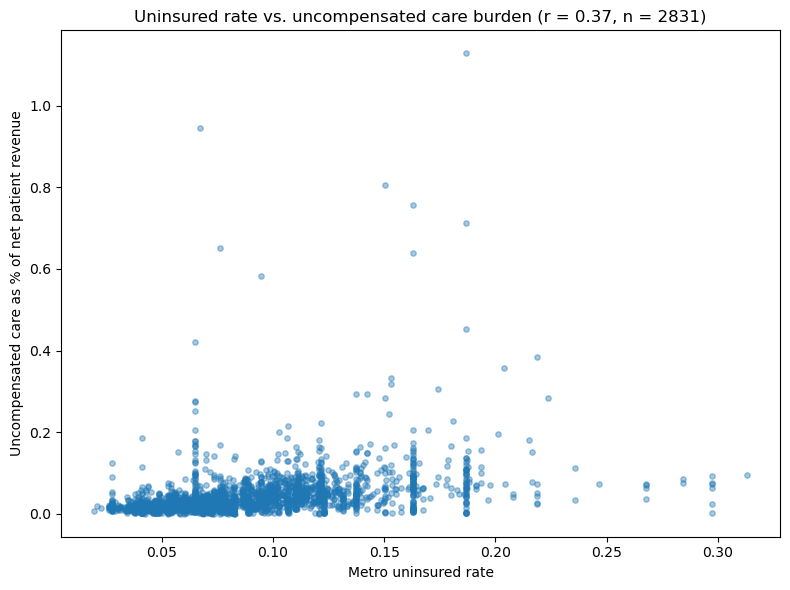

In [16]:
# Saved alongside the Day 5 lineage graph, the other portfolio image already in this repo.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(clean["uninsured_rate"], clean["uncompensated_pct_of_revenue"], alpha=0.4, s=15)
ax.set_xlabel("Metro uninsured rate")
ax.set_ylabel("Uncompensated care as % of net patient revenue")
ax.set_title(f"Uninsured rate vs. uncompensated care burden (r = {r:.2f}, n = {len(clean)})")
fig.tight_layout()
fig.savefig("../dbt/cms_spine/docs/burden_scatter.png", dpi=150)
plt.show()

In [17]:
# Outlier check: is the correlation being driven by a couple of extreme hospitals?
clean.sort_values("uncompensated_pct_of_revenue", ascending=False)[
    ["hospital_name", "metro_name", "uninsured_rate", "uncompensated_pct_of_revenue"]
].head()

,hospital_name,metro_name,uninsured_rate,uncompensated_pct_of_revenue
1160,HARRIS HEALTH,"Houston-Pasadena-The Woodlands, TX Metro Area",0.186889,1.128508
37,"PINEVILLE COMMUNITY HEALTH CENTER, INC","Middlesborough, KY Micro Area",0.067269,0.946095
2284,TEXAS CENTER FOR INFECTIOUS DISEASE,"San Antonio-New Braunfels, TX Metro Area",0.150313,0.805879
1604,PARKLAND HEALTH & HOSPITAL SYSTEM,"Dallas-Fort Worth-Arlington, TX Metro Area",0.163107,0.757817
2483,ELITE HOSPITAL KINGWOOD,"Houston-Pasadena-The Woodlands, TX Metro Area",0.186889,0.711472


In [18]:
# Recompute with the top 2 most extreme hospitals removed.
no_outliers = clean.sort_values("uncompensated_pct_of_revenue", ascending=False).iloc[2:]
r_no_outliers, p_no_outliers = stats.pearsonr(
    no_outliers["uninsured_rate"], no_outliers["uncompensated_pct_of_revenue"]
)
print(f"r without top 2 outliers = {r_no_outliers:.3f} (was {r:.3f} with them)")

r without top 2 outliers = 0.406 (was 0.370 with them)


**Interpretation:** across 2,831 hospitals with both fields populated, uninsured rate and
uncompensated care burden are positively correlated (r = 0.37, p « 0.001) — a moderate
relationship by the standard r-thresholds (0.3–0.5), not a "strong" one. It's statistically
robust given the sample size, but uninsured rate alone leaves most of the variation in
uncompensated care burden unexplained.

The top 5 hospitals by burden are Harris Health and Parkland — both well-known Texas
public safety-net systems in high-uninsured metros — plus a rural Kentucky community
health center and two smaller specialty/independent hospitals with unusually small revenue
denominators. Removing the top 2 outliers moves r from 0.37 to 0.41 — if anything the
correlation gets *slightly stronger* without them, so this isn't a case of a couple of
extreme points manufacturing a relationship that isn't really there.

# Findings

1. **Ownership type does not predict charity care per bed.** Nonprofit hospitals averaged
   somewhat higher charity care per bed than for-profit hospitals (\$41.5K vs \$38.1K), but
   the difference was not statistically significant (Welch's t-test, p ≈ 0.13) and the
   effect size was negligible (Cohen's d ≈ 0.07). This is a genuine null result, not a
   failed analysis — whatever drives charity-care generosity, it isn't well explained by
   the nonprofit/for-profit label alone.

2. **Service-line margins are only reliably negative for a handful of lines.** Obstetrics,
   Gastroenterology, and the residual "Other" category have 95% confidence intervals
   entirely below zero — consistent, real losses even where sample size is modest.
   Renal/Urology, Pulmonology, General Medicine, and Psychiatry are consistently
   profitable. Oncology has the highest mean margin of any line but also one of the widest
   confidence intervals (-\$1,169 to +\$4,395) — high average profitability driven by a
   small number of high-variance cases, not a stable finding.

3. **Higher-uninsured metros do have higher uncompensated care burden, moderately.**
   Pearson r = 0.37 (p « 0.001, n = 2,831) — positive and statistically robust, but a
   moderate relationship, not a strong one, and not driven by a couple of outlier
   hospitals (r actually rises slightly to 0.41 with the two most extreme points removed).
   Uninsured rate is one real driver of uncompensated care burden, not the whole story.